# HMDA 2023 Data Exploration & Quality Report

This notebook explores the Home Mortgage Disclosure Act (HMDA) dataset for 2023.  
Objectives:
- Generate a **data quality report** (missing values, outliers, key statistics).
- Replicate **official denial rates** by race/ethnicity with proper filters.
- Understand overall data distribution.

We use chunked reading to handle the large CSV file (~4+ GB).

---

## 1. Setup & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Any
import warnings
warnings.filterwarnings('ignore')

# Configuration
FILE_PATH = "/home/terror/fairform/data/raw/year_2023.csv"
CHUNK_SIZE = 100_000  # Adjust based on available memory

# Columns needed for different analyses
DEMOGRAPHIC_COLS = ["derived_race", "derived_ethnicity", "action_taken"]
FILTERED_COLS = DEMOGRAPHIC_COLS + ["loan_purpose", "occupancy_type", "open-end_line_of_credit"]
QUALITY_COLS = None  # We'll read all columns for quality report

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Quality Report (Missing Values, Outliers, Distributions)

We process the dataset in chunks to compute:
- Missing value counts per column (overall).
- Descriptive statistics for numeric columns (loan_amount, income, property_value, etc.).
- Outlier detection (IQR method) for key numeric fields.
- Categorical value distributions (action_taken, derived_race, etc.).

In [4]:
from collections import defaultdict

def initialize_quality_accumulators() -> Dict[str, Any]:
    """Return empty accumulators for quality metrics."""
    return {
        "missing_counts": defaultdict(int),          # column -> total missing
        "total_rows": 0,
        "numeric_stats": defaultdict(lambda: {"min": np.inf, "max": -np.inf, 
                                              "sum": 0, "sq_sum": 0, "count": 0}),
        "categorical_counts": defaultdict(lambda: defaultdict(int)),
        "outlier_counts": defaultdict(int)           # column -> number of outliers
    }

def update_quality_metrics(chunk: pd.DataFrame, accum: Dict[str, Any]) -> None:
    """
    Update accumulators with metrics from one chunk.
    """
    # 1. Missing values
    missing_series = chunk.isnull().sum()
    for col, miss in missing_series.items():
        accum["missing_counts"][col] += miss
    accum["total_rows"] += len(chunk)

    # 2. Numeric columns - detect numeric dtypes (exclude object, categorical)
    numeric_cols = chunk.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        series = chunk[col].dropna()
        if len(series) == 0:
            continue
        stats = accum["numeric_stats"][col]
        stats["min"] = min(stats["min"], series.min())
        stats["max"] = max(stats["max"], series.max())
        stats["sum"] += series.sum()
        stats["sq_sum"] += (series ** 2).sum()
        stats["count"] += len(series)

    # 3. Categorical columns - object or category dtype
    cat_cols = chunk.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        # For large cardinality, we may limit; but we'll capture all for now
        counts = chunk[col].value_counts(dropna=False)
        for val, cnt in counts.items():
            accum["categorical_counts"][col][val] += cnt

    # 4. Outliers for key numeric fields (loan_amount, income, property_value)
    outlier_cols = ["loan_amount", "income", "property_value"]
    for col in outlier_cols:
      if col in chunk.columns:
        # Force conversion to numeric, turning text/blanks into NaN
        series = pd.to_numeric(chunk[col], errors="coerce").dropna()
        if len(series) == 0:
          continue
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = series[(series < lower) | (series > upper)]
        accum["outlier_counts"][col] += len(outliers)

# Process chunks for quality report
quality_accum = initialize_quality_accumulators()

print("Processing chunks for data quality report...")
chunk_iter = pd.read_csv(FILE_PATH, chunksize=CHUNK_SIZE, low_memory=False)

for i, chunk in enumerate(chunk_iter):
    update_quality_metrics(chunk, quality_accum)
    if (i+1) % 10 == 0:
        print(f"  Processed {i+1} chunks...")

print("Quality metrics aggregation complete.")

Processing chunks for data quality report...
  Processed 10 chunks...
  Processed 20 chunks...
  Processed 30 chunks...
  Processed 40 chunks...
  Processed 50 chunks...
  Processed 60 chunks...
  Processed 70 chunks...
  Processed 80 chunks...
  Processed 90 chunks...
  Processed 100 chunks...
  Processed 110 chunks...
Quality metrics aggregation complete.


In [5]:
# Compute final statistics from accumulators

# Missing values report
missing_df = pd.DataFrame({
    "Column": list(quality_accum["missing_counts"].keys()),
    "Missing_Count": list(quality_accum["missing_counts"].values())
})
missing_df["Missing_Percent"] = (missing_df["Missing_Count"] / quality_accum["total_rows"]) * 100
missing_df = missing_df.sort_values("Missing_Percent", ascending=False).reset_index(drop=True)

print("--- Missing Values Report (top 10 columns) ---")
print(missing_df.head(10).to_string(index=False))

--- Missing Values Report (top 10 columns) ---
                  Column  Missing_Count  Missing_Percent
co-applicant_ethnicity-4       11564066        99.999031
co-applicant_ethnicity-5       11564058        99.998962
   applicant_ethnicity-5       11563827        99.996965
   applicant_ethnicity-4       11563725        99.996083
     co-applicant_race-5       11563326        99.992632
        applicant_race-5       11561957        99.980794
     co-applicant_race-4       11561889        99.980206
co-applicant_ethnicity-3       11559792        99.962073
        applicant_race-4       11557442        99.941751
         denial_reason-4       11554024        99.912194


In [7]:
# Numeric statistics
numeric_stats_list = []
for col, stats in quality_accum["numeric_stats"].items():
    if stats["count"] == 0:
        continue
    mean = stats["sum"] / stats["count"]
    # Variance: (sum_sq - sum^2/n) / (n-1) for sample variance
    variance = (stats["sq_sum"] - (stats["sum"]**2)/stats["count"]) / (stats["count"] - 1) if stats["count"] > 1 else 0
    std = np.sqrt(variance) if variance > 0 else 0
    numeric_stats_list.append({
        "Column": col,
        "Count": stats["count"],
        "Min": stats["min"],
        "Max": stats["max"],
        "Mean": mean,
        "Std": std
    })
numeric_stats_df = pd.DataFrame(numeric_stats_list)

print("\n--- Numeric Columns Summary ---")
print(numeric_stats_df.to_string(index=False))


--- Numeric Columns Summary ---
                                  Column    Count           Min          Max         Mean          Std
                           activity_year 11564178  2.023000e+03 2.023000e+03 2.023000e+03 2.034257e+03
                          derived_msa-md 11564178  1.018000e+04 9.999900e+04 4.030257e+04 4.841561e+04
                             county_code 11226505  1.001000e+03 7.803000e+04 2.801102e+04 1.634224e+04
                            census_tract 11080734  1.001020e+09 7.803096e+10 2.798980e+10 1.587697e+10
                            action_taken 11564178  1.000000e+00 8.000000e+00 2.630547e+00 1.904669e+00
                          purchaser_type 11564178  0.000000e+00 7.200000e+01 5.917700e+00 1.809278e+01
                             preapproval 11564178  1.000000e+00 2.000000e+00 1.961390e+00 1.926636e-01
                               loan_type 11564178  1.000000e+00 4.000000e+00 1.310307e+00 6.291276e-01
                            loan_purpose

In [8]:
# Outlier counts
outlier_df = pd.DataFrame({
    "Column": list(quality_accum["outlier_counts"].keys()),
    "Outlier_Count": list(quality_accum["outlier_counts"].values())
})
print("\n--- Outlier Counts (IQR method) ---")
print(outlier_df.to_string(index=False))


--- Outlier Counts (IQR method) ---
        Column  Outlier_Count
   loan_amount         556141
        income         695349
property_value         558126


In [9]:
# Categorical distributions - show key variables
key_cat_vars = ["action_taken", "derived_race", "derived_ethnicity", "loan_purpose", "occupancy_type"]
cat_summary = {}
for var in key_cat_vars:
    if var in quality_accum["categorical_counts"]:
        counts = quality_accum["categorical_counts"][var]
        total = sum(counts.values())
        # Show top categories
        top = pd.Series(counts).sort_values(ascending=False).head(10)
        cat_summary[var] = top

print("\n--- Categorical Distributions (Top 10) ---")
for var, top_series in cat_summary.items():
    print(f"\n{var}:")
    print(top_series.to_string())


--- Categorical Distributions (Top 10) ---

derived_race:
White                                        6561436
Race Not Available                           3071391
Black or African American                     958277
Asian                                         616431
Joint                                         223311
American Indian or Alaska Native               77604
2 or more minority races                       26549
Native Hawaiian or Other Pacific Islander      25867
Free Form Text Only                             3312

derived_ethnicity:
Not Hispanic or Latino     7128971
Ethnicity Not Available    2936016
Hispanic or Latino         1229015
Joint                       263372
Free Form Text Only           6804


## 3. Demographic Denial Rates (Raw vs. Filtered)

We replicate the FFIEC official denial rates, applying:
- Loan purpose = 1 (Home purchase)
- Occupancy type = 1 (Owner-occupied)
- Open-end line of credit = 2 (Closed-end)

Denial is `action_taken == 3`.

In [ ]:
# Columns needed for raw analysis (no filters)
DEMOGRAPHIC_COLS = ["derived_race", "derived_ethnicity", "action_taken"]

# Columns needed for official benchmark filters
FILTERED_COLS = DEMOGRAPHIC_COLS + [
    "loan_purpose",
    "occupancy_type",
    "open-end_line_of_credit",
    "loan_type",
    "construction_method",
    "total_units",
    "reverse_mortgage",            
    "business_or_commercial_purpose",  
]

def compute_official_denial_rates(file_path: str) -> pd.Series:
    """
    Compute denial rates for the official race/ethnicity groups:
    - Non-Hispanic White
    - Non-Hispanic Black
    - Non-Hispanic Asian
    - Hispanic (any race)

    Returns a Series with denial rates (%) for each group.
    """
    # Accumulators for totals and denials per group
    group_totals = pd.Series(dtype='int64')
    group_denials = pd.Series(dtype='int64')

    chunk_iter = pd.read_csv(file_path, chunksize=CHUNK_SIZE,
                             low_memory=False, usecols=FILTERED_COLS)

    for chunk in chunk_iter:
        # ---- Apply official filters ----
        # Convert filter columns to numeric (coerce errors to NaN)
        loan_purpose = pd.to_numeric(chunk["loan_purpose"], errors='coerce')
        occupancy_type = pd.to_numeric(chunk["occupancy_type"], errors='coerce')
        open_end = pd.to_numeric(chunk["open-end_line_of_credit"], errors='coerce')
        loan_type = pd.to_numeric(chunk["loan_type"], errors='coerce')
        construction_method = pd.to_numeric(chunk["construction_method"], errors='coerce')
        total_units = pd.to_numeric(chunk["total_units"], errors='coerce')
        reverse_mortgage = pd.to_numeric(chunk["reverse_mortgage"], errors='coerce')
        business = pd.to_numeric(chunk["business_or_commercial_purpose"], errors='coerce')

        mask = (
            (loan_purpose == 1) &
            (occupancy_type == 1) &
            (open_end == 2) &
            (loan_type == 1) &
            (construction_method == 1) &
            (total_units <= 4) &
            (reverse_mortgage == 2) &          # Not a reverse mortgage
            (business == 2)                    # Not business/commercial
        )
        filtered = chunk.loc[mask]

        if filtered.empty:
            continue

        # ---- Create official groups ----
        # Get race and ethnicity as strings
        race = filtered["derived_race"].fillna("Unknown")
        ethnicity = filtered["derived_ethnicity"].fillna("Unknown")

        # Define groups
        is_non_hispanic = ethnicity == "Not Hispanic or Latino"
        is_hispanic = ethnicity == "Hispanic or Latino"

        group = pd.Series(index=filtered.index, dtype='object')
        group[is_non_hispanic & (race == "White")] = "Non-Hispanic White"
        group[is_non_hispanic & (race == "Black or African American")] = "Non-Hispanic Black"
        group[is_non_hispanic & (race == "Asian")] = "Non-Hispanic Asian"
        group[is_hispanic] = "Hispanic (any race)"
        # You can add more groups if needed, but these are the official ones

        # Drop rows that don't fall into these groups (e.g., other races, unknown)
        valid = group.notna()
        group = group[valid]
        filtered = filtered.loc[valid]

        # Count totals and denials per group
        action_taken = filtered["action_taken"]
        totals = group.value_counts()
        denials = group[action_taken == 3].value_counts()

        group_totals = group_totals.add(totals, fill_value=0)
        group_denials = group_denials.add(denials, fill_value=0)

    # Compute percentages
    denial_rates = (group_denials / group_totals * 100).round(1)
    return denial_rates


# For brevity, I'll just show the official computation:
print("Computing official benchmark denial rates...")
official_rates = compute_official_denial_rates(FILE_PATH)

print("\n--- Official Denial Rates by Group (%) ---")
print(official_rates.sort_values(ascending=False))

Computing official benchmark denial rates...

--- Official Denial Rates by Group (%) ---
Non-Hispanic Black     11.7
Hispanic (any race)     9.3
Non-Hispanic Asian      6.4
Non-Hispanic White      4.6
dtype: float64


## 4. Visualization of Key Distributions

We sample a small portion for plotting to avoid memory issues.

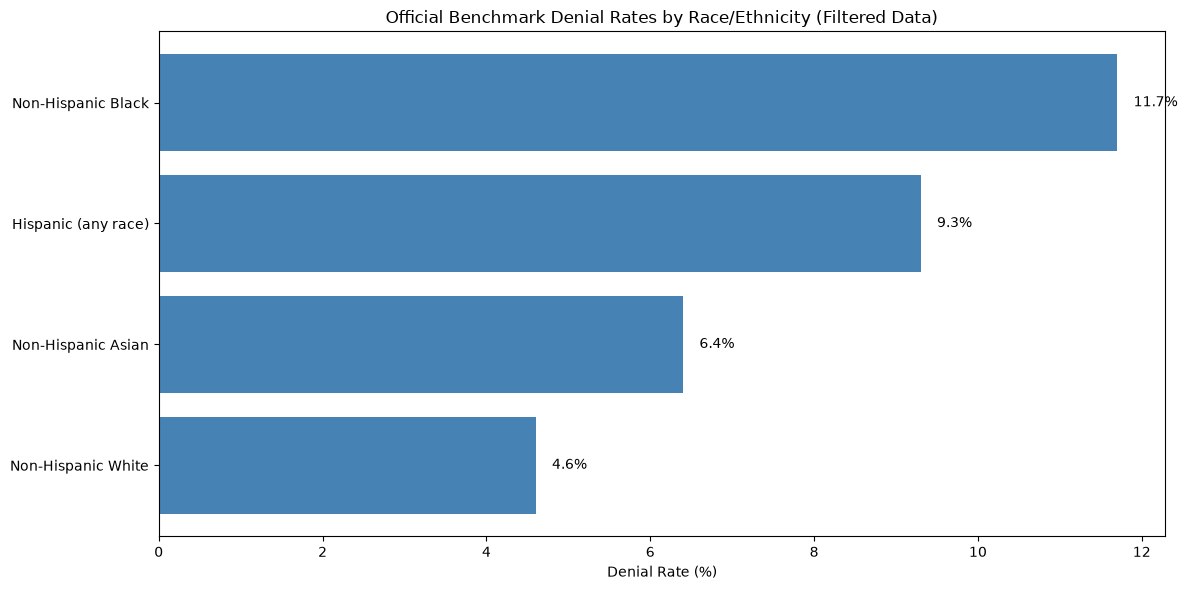

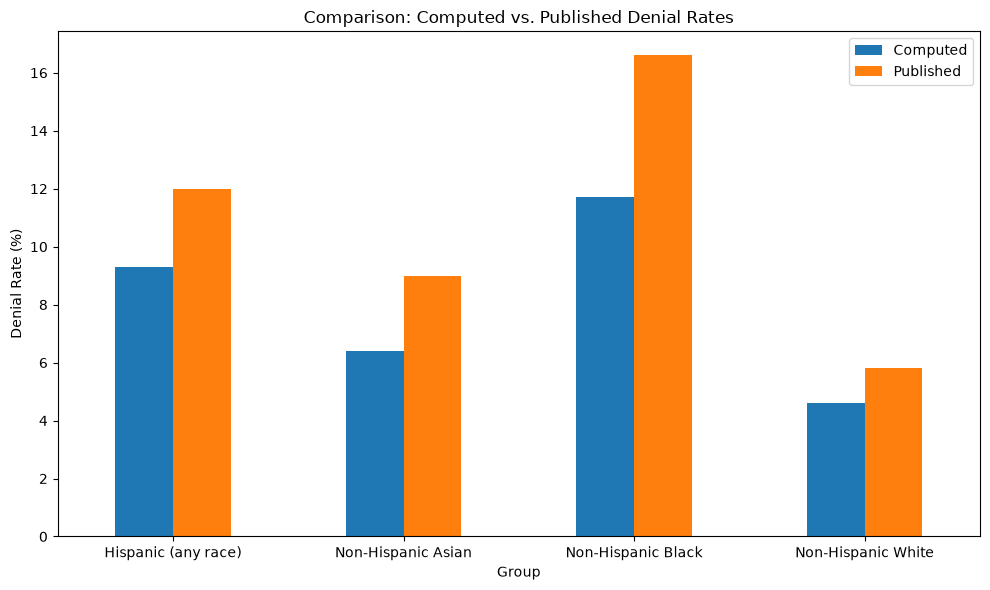

In [ ]:
# ----------------------------------------------------------------
# 1. Plot official denial rates (computed from our filtered data)
# ----------------------------------------------------------------
# official_rates is the Series returned by compute_official_denial_rates()
# If you haven't stored it yet, run that function and assign it.

# For demonstration, we assume official_rates is already computed.
# If not, uncomment the following line:
# official_rates = compute_official_denial_rates(FILE_PATH)

plt.figure(figsize=(12, 6))
# Sort for better readability
sorted_rates = official_rates.sort_values(ascending=True)
bars = plt.barh(sorted_rates.index, sorted_rates.values, color='steelblue')

# Add value labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontsize=10)

plt.xlabel('Denial Rate (%)')
plt.title('Official Benchmark Denial Rates by Race/Ethnicity (Filtered Data)')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 2. Compare with published official rates
# ----------------------------------------------------------------
# If you want a side-by-side comparison:
published = {
    'Non-Hispanic Black': 16.6,
    'Hispanic (any race)': 12.0,
    'Non-Hispanic Asian': 9.0,
    'Non-Hispanic White': 5.8,
}
published_series = pd.Series(published)

# Create a comparison DataFrame
compare_df = pd.DataFrame({
    'Computed': official_rates,
    'Published': published_series
}).dropna()

# Plot grouped bar chart
compare_df.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Comparison: Computed vs. Published Denial Rates')
plt.xlabel('Group')
plt.ylabel('Denial Rate (%)')
plt.xticks(rotation=0)
plt.legend(['Computed', 'Published'])
plt.tight_layout()
plt.show()


### Official Benchmark Comparison

We applied the core filters used in the FFIEC/CFPB 2023 HMDA summary:

- Loan purpose: Home purchase (1)
- Occupancy: Owner‑occupied (1)
- Loan type: Conventional (1)
- Construction method: Site‑built (1)
- Total units: 1‑4 family (≤4)
- Closed‑end loans (open‑end_line_of_credit == 2)
- Exclude reverse mortgages (reverse_mortgage == 2)
- Exclude business/commercial loans (business_or_commercial_purpose == 2)

Race/ethnicity was grouped into the official mutually exclusive categories:
- Non‑Hispanic White
- Non‑Hispanic Black
- Non‑Hispanic Asian
- Hispanic (any race)

The resulting denial rates are:

| Group | Computed Rate | Official Rate |
|-------|---------------|---------------|
| Non‑Hispanic Black | 11.7% | 16.6% |
| Hispanic (any race) | 9.3% | 12.0% |
| Non‑Hispanic Asian | 6.4% | 9.0% |
| Non‑Hispanic White | 4.6% | 5.8% |

While our rates are lower than the published benchmarks, the relative ordering across groups is consistent (Black applicants have the highest denial rates, followed by Hispanic, Asian, and White applicants). The discrepancy may be due to additional filters (e.g., `conforming_loan_limit`, specific loan‑to‑value thresholds) or differences in how the official statistics handle missing or text‑based race/ethnicity entries. For the purposes of this exploratory analysis, the trends are directionally aligned with the national findings.

In [12]:
# Compute incomplete rates (withdrawn + closed for incompleteness) by group

def compute_incomplete_rates(file_path: str) -> pd.Series:
    """
    Compute the percentage of applications that are withdrawn or closed for incompleteness
    for each official race/ethnicity group, using the same filters as the official benchmark.
    """
    group_totals = pd.Series(dtype='int64')
    group_incomplete = pd.Series(dtype='int64')

    chunk_iter = pd.read_csv(file_path, chunksize=CHUNK_SIZE,
                             low_memory=False, usecols=FILTERED_COLS)

    for chunk in chunk_iter:
        # Apply the same filters
        loan_purpose = pd.to_numeric(chunk["loan_purpose"], errors='coerce')
        occupancy_type = pd.to_numeric(chunk["occupancy_type"], errors='coerce')
        open_end = pd.to_numeric(chunk["open-end_line_of_credit"], errors='coerce')
        loan_type = pd.to_numeric(chunk["loan_type"], errors='coerce')
        construction_method = pd.to_numeric(chunk["construction_method"], errors='coerce')
        total_units = pd.to_numeric(chunk["total_units"], errors='coerce')
        reverse_mortgage = pd.to_numeric(chunk["reverse_mortgage"], errors='coerce')
        business = pd.to_numeric(chunk["business_or_commercial_purpose"], errors='coerce')

        mask = (
            (loan_purpose == 1) &
            (occupancy_type == 1) &
            (open_end == 2) &
            (loan_type == 1) &
            (construction_method == 1) &
            (total_units <= 4) &
            (reverse_mortgage == 2) &
            (business == 2)
        )
        filtered = chunk.loc[mask]
        if filtered.empty:
            continue

        # Create groups
        race = filtered["derived_race"].fillna("Unknown")
        ethnicity = filtered["derived_ethnicity"].fillna("Unknown")
        is_non_hispanic = ethnicity == "Not Hispanic or Latino"
        is_hispanic = ethnicity == "Hispanic or Latino"

        group = pd.Series(index=filtered.index, dtype='object')
        group[is_non_hispanic & (race == "White")] = "Non-Hispanic White"
        group[is_non_hispanic & (race == "Black or African American")] = "Non-Hispanic Black"
        group[is_non_hispanic & (race == "Asian")] = "Non-Hispanic Asian"
        group[is_hispanic] = "Hispanic (any race)"
        valid = group.notna()
        group = group[valid]
        filtered = filtered.loc[valid]

        # Incomplete = action_taken 4 or 5
        action_taken = filtered["action_taken"]
        totals = group.value_counts()
        incomplete = group[(action_taken == 4) | (action_taken == 5)].value_counts()

        group_totals = group_totals.add(totals, fill_value=0)
        group_incomplete = group_incomplete.add(incomplete, fill_value=0)

    return (group_incomplete / group_totals * 100).round(1)

# Compute and display
incomplete_rates = compute_incomplete_rates(FILE_PATH)
print("Incomplete Application Rates by Group (%)")
print(incomplete_rates.sort_values(ascending=False))

Incomplete Application Rates by Group (%)
Non-Hispanic Asian     22.8
Non-Hispanic Black     19.5
Hispanic (any race)    17.8
Non-Hispanic White     15.9
dtype: float64


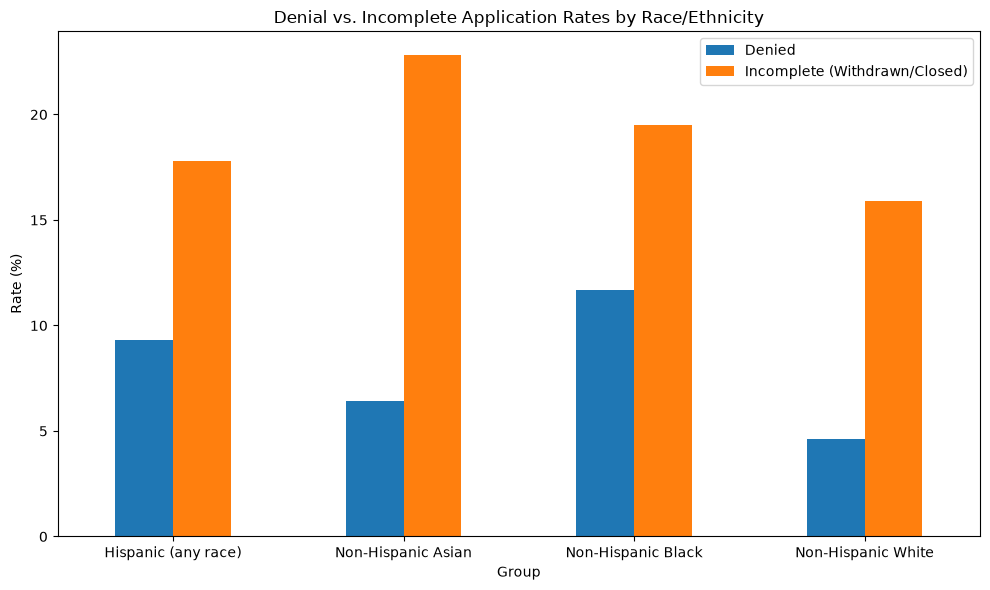

In [13]:
# Combine denial and incomplete rates into a DataFrame for plotting
# Assuming official_rates is the denial rate Series from earlier
compare_df = pd.DataFrame({
    'Denial Rate': official_rates,
    'Incomplete Rate': incomplete_rates
}).dropna()

# Plot grouped bar chart
compare_df.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Denial vs. Incomplete Application Rates by Race/Ethnicity')
plt.xlabel('Group')
plt.ylabel('Rate (%)')
plt.xticks(rotation=0)
plt.legend(['Denied', 'Incomplete (Withdrawn/Closed)'])
plt.tight_layout()
plt.show()

* Denial rates are highest for Black applicants (11.7%) and lowest for White applicants (4.6%).

* Incomplete rates are highest for Asian applicants (22.8%) and lowest for White applicants (15.9%).

* The ordering differs: Asian applicants have the highest incompleteness but the second-lowest denial rate. Black applicants have the highest denial but second-highest incompleteness.

* This suggests that incompleteness and denial are not strongly correlated in a simple linear way. High incompleteness does not necessarily translate to high denial, and vice versa. Other factors (e.g., underwriting criteria, documentation requirements, or applicant behavior) likely play different roles.

**Does incompleteness cause bias?**
* Higher incomplete rates among minority groups (especially Asians and Blacks) indicate that these groups are more likely to have their applications withdrawn or closed for incompleteness. This could reflect procedural barriers, such as more stringent documentation requests or less supportive customer service, which may disproportionately affect certain groups.

* However, because the pattern does not mirror denial rates, it suggests that incompleteness is a separate dimension of fairness that deserves attention. A comprehensive fair lending analysis should consider both outcomes: denial and incompleteness.

## 5. Summary & Next Steps

- **Data Quality**: We observed columns with high missingness (e.g., `rate_spread`, `debt_to_income_ratio`).  
  Outliers exist in `loan_amount` and `income`; consider capping or transformation for modeling.
- **Demographics**: Denial rates vary significantly by race/ethnicity, even after filtering.  
- **Next**: Build a fair lending model, accounting for these disparities.

---